In [1]:
import os
import re
from io import StringIO

import pandas as pd

In [2]:
MULTIROW_PATTERN = re.compile(r"^\\multirow\[[^\]]+\]\{(\d+)\}\{\*\}\{(.*)\}$")


def parse_latex_table(filepath: os.PathLike, set_index: bool = True) -> pd.DataFrame:
    with open(filepath) as f:
        s = "".join(
            line.replace(r"\%", r"%").replace("\\\\\n", "\n")
            for line in f
            if not any(
                x in line
                for x in [
                    r"\begin{tabular}",
                    r"\toprule",
                    r"\midrule",
                    r"\cline",
                    r"\bottomrule",
                    r"\end{tabular}",
                ]
            )
        )
    pre = pd.read_table(StringIO(s), sep=r"\s*&\s*", engine="python", header=None)
    header = pre.loc[0].combine_first(pre.loc[1])
    index = list(pre.loc[1][pre.loc[1].notnull()])
    mid = pre.loc[2:].reset_index(drop=True).rename(columns=header)
    for c in index:
        i = 0
        while i < len(mid[c]):
            m = MULTIROW_PATTERN.match(str(mid[c].iloc[i]))
            if m is None:
                i += 1
            else:
                skip = int(m.group(1))
                mid.loc[i : i + skip - 1, c] = m.group(2)
                i += skip
    full = mid.fillna("")
    if set_index:
        full = full.set_index(index)
    return full

In [3]:
from matplotlib import pyplot as plt

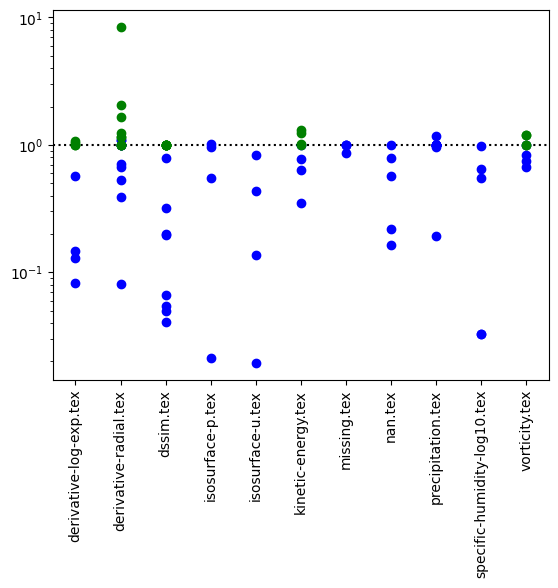

In [4]:
tables = [
    "derivative-log-exp.tex",
    "derivative-radial.tex",
    "dssim.tex",
    "isosurface-p.tex",
    "isosurface-u.tex",
    "kinetic-energy.tex",
    "missing.tex",
    "nan.tex",
    "precipitation.tex",
    "specific-humidity-log10.tex",
    "vorticity.tex",
]

fig, ax = plt.subplots()

ax.axhline(1, c="k", zorder=-1, ls=":")

for i, table in enumerate(tables):
    crc = "CR (any NaN)" if table == "nan.tex" else "CR"
    cr = parse_latex_table(table, set_index=True)[crc]
    cr = pd.to_numeric(cr.str.removeprefix(r"$\times$ "), errors="coerce")

    lossless = cr[cr.index.get_level_values("Corrections") == "lossless"].droplevel(
        "Corrections"
    )
    oneshot = cr[cr.index.get_level_values("Corrections") == "one-shot"].droplevel(
        "Corrections"
    )
    iterative = cr[cr.index.get_level_values("Corrections") == "iterative"].droplevel(
        "Corrections"
    )

    ax.scatter([i] * len(oneshot), lossless / oneshot, c="blue")
    ax.scatter([i] * len(oneshot), iterative / oneshot, c="green")

ax.set_yscale("log")
ax.set_xticks(list(range(len(tables))))
ax.set_xticklabels(tables, rotation=90)

plt.show()